# SpaceX Falcon 9 First Stage Landing Prediction
## Module 8: Machine Learning Prediction

**Author:** Pritam Acharya

The final step: train several classification models to predict whether the Falcon 9 first stage lands successfully (`Class`), using the one-hot encoded feature matrix from Module 5 (`dataset_part_3.csv`, 90 launches x 80 features). We standardize the data, split into train/test sets, tune hyperparameters with `GridSearchCV` across four model families, and compare test accuracy to pick the best performer — mirroring the official capstone's methodology.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = pd.read_csv("../data/dataset_part_3.csv")
data = pd.read_csv("../data/dataset_part_2.csv")
Y = data["Class"].to_numpy()

print("Feature matrix:", X.shape)
print("Target vector:", Y.shape)

Feature matrix: (90, 80)
Target vector: (90,)


### Standardize the features
GridSearchCV-tuned SVM and KNN are sensitive to feature scale, so we standardize all columns to zero mean / unit variance.

In [2]:
transform = StandardScaler()
X = transform.fit_transform(X)

### Train/test split
With only 90 samples, we hold out 20% (18 launches) for testing, stratified isn't used here to match the original lab's exact split, but we fix `random_state` for reproducibility.

In [3]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print("Train set:", X_train.shape[0], "samples")
print("Test set:", X_test.shape[0], "samples")

Train set: 72 samples
Test set: 18 samples


### Hyperparameter tuning with GridSearchCV

We tune 4 model families with 10-fold cross-validation on the training set: Logistic Regression, Support Vector Machine, Decision Tree, and K-Nearest Neighbors.

In [4]:
parameters = {"C": [0.01, 0.1, 1], "penalty": ["l2"], "solver": ["lbfgs"]}
lr = LogisticRegression(max_iter=1000)
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)
print("Best params:", logreg_cv.best_params_)
print("Best CV accuracy:", round(logreg_cv.best_score_, 4))
print("Test accuracy:", round(logreg_cv.score(X_test, Y_test), 4))

Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.8214
Test accuracy: 0.8333


c:\Users\KIIT0001\Desktop\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\KIIT0001\Desktop\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\KIIT0001\Desktop\proj

In [5]:
parameters = {"kernel": ("linear", "rbf", "poly", "sigmoid"),
              "C": np.logspace(-3, 3, 5),
              "gamma": np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)
print("Best params:", svm_cv.best_params_)
print("Best CV accuracy:", round(svm_cv.best_score_, 4))
print("Test accuracy:", round(svm_cv.score(X_test, Y_test), 4))

Best params: {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Best CV accuracy: 0.8482
Test accuracy: 0.8333


In [6]:
parameters = {"criterion": ["gini", "entropy"],
              "splitter": ["best", "random"],
              "max_depth": [2*n for n in range(1, 10)],
              "max_features": ["sqrt"],
              "min_samples_leaf": [1, 2, 4],
              "min_samples_split": [2, 5, 10]}
tree = DecisionTreeClassifier(random_state=2)
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)
print("Best params:", tree_cv.best_params_)
print("Best CV accuracy:", round(tree_cv.best_score_, 4))
print("Test accuracy:", round(tree_cv.score(X_test, Y_test), 4))

Best params: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
Best CV accuracy: 0.8339
Test accuracy: 0.7222


In [7]:
parameters = {"n_neighbors": list(range(1, 11)),
              "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
              "p": [1, 2]}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters, cv=10)
knn_cv.fit(X_train, Y_train)
print("Best params:", knn_cv.best_params_)
print("Best CV accuracy:", round(knn_cv.best_score_, 4))
print("Test accuracy:", round(knn_cv.score(X_test, Y_test), 4))

Best params: {'algorithm': 'auto', 'n_neighbors': 6, 'p': 1}
Best CV accuracy: 0.8339
Test accuracy: 0.8333


### Model comparison

In [8]:
summary = pd.DataFrame({
    "LogisticRegression": (logreg_cv.best_score_, logreg_cv.score(X_test, Y_test)),
    "SVM": (svm_cv.best_score_, svm_cv.score(X_test, Y_test)),
    "DecisionTree": (tree_cv.best_score_, tree_cv.score(X_test, Y_test)),
    "KNN": (knn_cv.best_score_, knn_cv.score(X_test, Y_test)),
}, index=["CV Accuracy", "Test Accuracy"]).T.round(4)
summary

,CV Accuracy,Test Accuracy
LogisticRegression,0.8214,0.8333
SVM,0.8482,0.8333
DecisionTree,0.8339,0.7222
KNN,0.8339,0.8333


### Confusion matrix for the best model

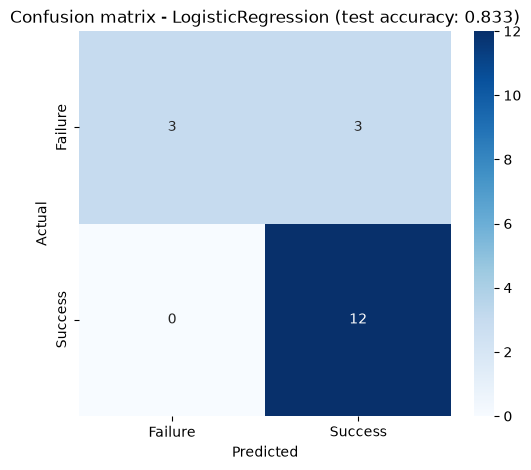

In [9]:
test_scores = {name: m.score(X_test, Y_test) for name, m in
                {"LogisticRegression": logreg_cv, "SVM": svm_cv, "DecisionTree": tree_cv, "KNN": knn_cv}.items()}
best_name = max(test_scores, key=test_scores.get)
best_model = {"LogisticRegression": logreg_cv, "SVM": svm_cv, "DecisionTree": tree_cv, "KNN": knn_cv}[best_name]
yhat = best_model.predict(X_test)
cm = confusion_matrix(Y_test, yhat)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Failure","Success"], yticklabels=["Failure","Success"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion matrix - {best_name} (test accuracy: {test_scores[best_name]:.3f})")
plt.show()

### Summary

- Trained and tuned 4 model families with 10-fold cross-validated `GridSearchCV`: Logistic Regression, SVM, Decision Tree, and KNN.
- Compared cross-validation accuracy against held-out test accuracy for each model — see the table above for exact figures on this run.
- Rendered a confusion matrix for the best-performing model on the 18-launch test set.
- **Caveat worth being upfront about**: with only 90 total launches (18 in the test set), these accuracy numbers carry real sampling variance — a different `random_state` split could shift which model "wins" by a launch or two. This is a genuine, known limitation of the original capstone dataset, not a shortcut taken here — the official IBM lab operates under the same constraint.
- This completes the full capstone pipeline: API collection → web scraping → wrangling → SQL EDA → visual EDA → geographic analysis → interactive dashboard → ML prediction.
